<div class="alert alert-block alert-success">
    <h1 align="center">House price prediction (Tehran) Using Machine Learning</h1>
    <h3 align="center">Dataset is crawled from Divar.ir</h3>
    
<a href="https://www.kaggle.com/code/soheiltehranipour/tehran-divar-ir-house-price-prediction/input">
Click for more information for dataset
    </a>
</div>

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/2/29/Tehran_in_a_clean_day.jpg/1280px-Tehran_in_a_clean_day.jpg" />

<div style="
    background-color: #e6f9e6;
    border-left: 6px solid #4caf50;
    padding: 15px 20px;
    border-radius: 8px;
    margin: 15px 0;
    font-size: 16px;
    line-height: 1.5;    
">
Welcome to this notebook!  

In this project, we're going to use machine learning tools to predict house prices in Tehran, the capital city of Iran.

</div>

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        Topics:
    </p>
    <ul style="margin:0;padding-left:20px;">
        <li>Import the Dataset (House Prices in Tehran)</li>
        <li>Exploratory Data Analysis (Question-driven EDA)</li>
        <li>Preprocessing (Handling Missing Values, Encoding data, Scale & Cross-validation)</li>
        <li>Model building, performance evaluation, and hyperparameter tuning</li>
        <li>Identifying the best-performing model and saving it for future use</li>
    </ul>
</div>

<div style="
    background-color: #e6f9e6;
    border-left: 6px solid #4caf50;
    padding: 15px 20px;
    border-radius: 8px;
    margin: 15px 0;
    font-size: 16px;
    line-height: 1.5;    
">
Importing the libraries:

</div>

In [1]:
#pip install xgboost
#pip install lightgbm

In [2]:
import pandas as pd
import numpy as np 
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import re 
import time
import joblib
from tqdm.notebook import tqdm
#---
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
#---
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
#---
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
#---


import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns',None)
pd.set_option('display.precision', 8)
sns.set(style="darkgrid",font_scale=1.5)
colors = plt.get_cmap('tab10').colors

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        1. Loading Dataset:
    </p>
</div>

In [3]:
data = pd.read_csv('/kaggle/input/house-price-tehran-iran/housePrice.csv')

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        1-1. Basic Understanding of Dataset:
    </p>
</div>

In [4]:
display(data.info())
print("*"*50)

display(data.sample(3))
print("*"*50)

print('Duplicate Values:', data.duplicated().sum())
print("*"*50)

print(f"null_data:\n{data.isna().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3479 entries, 0 to 3478
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Area        3479 non-null   object 
 1   Room        3479 non-null   int64  
 2   Parking     3479 non-null   bool   
 3   Warehouse   3479 non-null   bool   
 4   Elevator    3479 non-null   bool   
 5   Address     3456 non-null   object 
 6   Price       3479 non-null   float64
 7   Price(USD)  3479 non-null   float64
dtypes: bool(3), float64(2), int64(1), object(2)
memory usage: 146.2+ KB


None

**************************************************


,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
1371,55,2,False,False,False,Parastar,1280000000.0,42666.67
1837,70,2,True,True,True,East Ferdows Boulevard,3000000000.0,100000.00
1040,96,2,True,True,True,Northern Janatabad,3900000000.0,130000.00


**************************************************
Duplicate Values: 208
**************************************************
null_data:
Area           0
Room           0
Parking        0
Warehouse      0
Elevator       0
Address       23
Price          0
Price(USD)     0
dtype: int64


<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:10px;">
        Description:
    </p>
    <ul style="margin:0;padding-left:20px;">
        <li>
            As it can be seen, two columns (Price and Price (USD)) are the same, so we use the Price column as our target value (y).
        </li>
        <li>
            Except for the Area feature, all other continuous features are numeric. We will change the data type of the Area feature later.
        </li>
        <li>
            There are some duplicate entries in the dataset and a few missing values in the Address feature. To avoid introducing outliers, we will simply remove these rows.
        </li>
    </ul>
</div>


<div style="
    background-color:#e6f9e6;
    border-left:6px solid #4caf50;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:16px;
    line-height:1.5;
">
    <p style="margin:0;font-weight:bold;">
        1-2. Before starting the EDA, we perform an initial data cleaning step to ensure the dataset is in a proper and usable format.
    </p>
</div>


In [5]:
# Remove comma separators from Price and convert it to numeric data type:
data.Area = data.Area.apply(lambda x: re.sub(',', '', x))
#change Data type
data.Area = pd.to_numeric(data.Area, errors='coerce')

#---Drop section
data.drop(columns='Price(USD)', inplace=True)
#Drop Duplicate Values:
data.drop_duplicates(inplace=True)
#Drop NUll values:
data.dropna(subset='Address', inplace=True)

print(f'data type: \n{data.dtypes}')
print(f'\ndata.duplicated: {data.duplicated().sum()}')

data type: 
Area           int64
Room           int64
Parking         bool
Warehouse       bool
Elevator        bool
Address       object
Price        float64
dtype: object

data.duplicated: 0


<div style="
    background-color:#e6f9e6;
    border-left:6px solid #4caf50;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:16px;
    line-height:1.5;
">
    <p style="margin:0;font-weight:bold;">
        3. Exploratory Data Analysis (Question-driven EDA):
    </p>

</div>


<div style="
    background-color: #FFE1FF;
    border-left: 6px solid #660066;
    padding: 15px 20px;
    border-radius: 8px;
    margin: 15px 0;
    font-size: 14px;
    line-height: 1.5;    
">
Q1: How are house prices distributed?
</div>

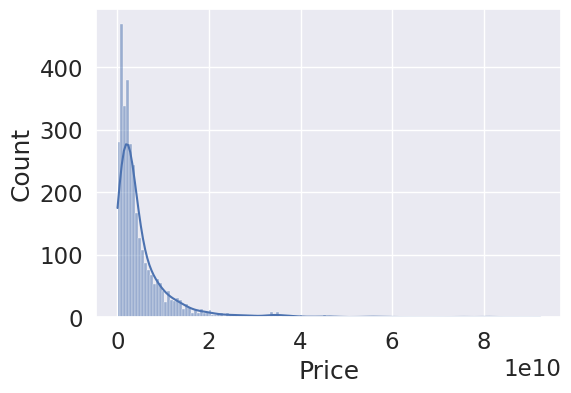

Price.skew: 4.727793225124293


In [6]:
plt.figure(figsize=(6,4))
sns.histplot(data, x='Price', kde=True)
plt.show()

print('Price.skew:', data.Price.skew())

<div style="
    background-color: #DCFBFC;
    border-left: 6px solid #10B8BC;
    padding: 15px 20px;
    border-radius: 8px;
    margin: 15px 0;
    font-size: 14px;
    line-height: 1.5;    
">
<h4> Description:</h4>
The distribution of house prices is <strong>right-skewed</strong>, with most observations concentrated in the lower one-third of the value range. Outliers are observed on the right side of the distribution, which we will handle later in the analysis.
</div>





<div style="
    background-color: #FFE1FF;
    border-left: 6px solid #660066;
    padding: 15px 20px;
    border-radius: 8px;
    margin: 15px 0;
    font-size: 14px;
    line-height: 1.5;    
">
Q2: How many bedrooms do most houses have?

</div>

<Axes: xlabel='Room'>

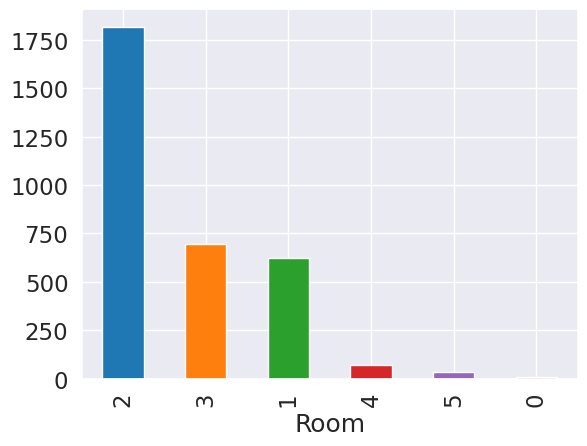

In [7]:
data.Room.value_counts().plot(kind='bar', color=colors)

<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:6px;">
        Description:
    </p>
    <ul style="margin-top:0;margin-bottom:10px;padding-left:20px;">
        <li>
            Most houses have 2 rooms. Counts for 1- and 3-room houses are similar. Only a small number have 4 or 5 rooms, and houses with zero rooms are rare.
        </li>
    </ul>
    <p style="font-weight:bold;margin-bottom:6px;">
        Conclusion:
    </p>
    <ul style="margin:0;padding-left:20px;">
        <li>
            The mean number of rooms is 2.
        </li>
    </ul>
</div>


<div style="
    background-color: #FFE1FF;
    border-left: 6px solid #660066;
    padding: 15px 20px;
    border-radius: 8px;
    margin: 15px 0;
    font-size: 14px;
    line-height: 1.5;    
">
Q3: Distribution of boolean features: Parking, Warehouse, Elevator
</div>

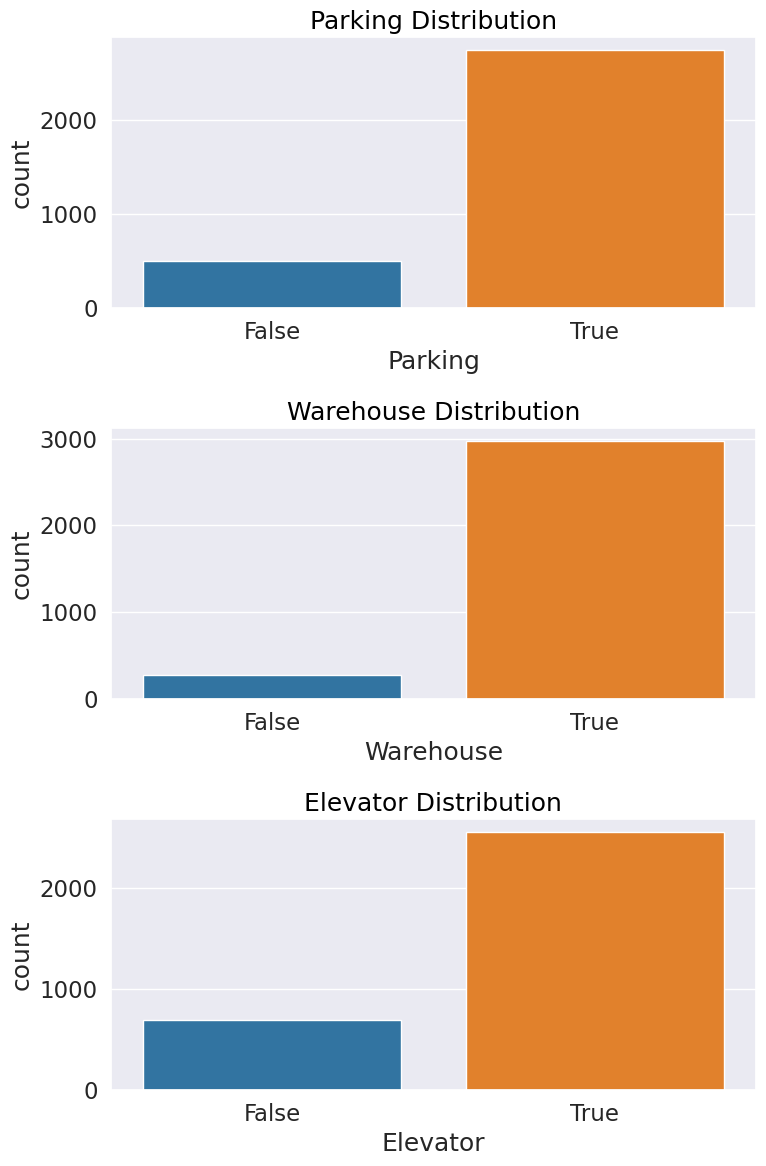

Parking value counts:
Parking
True     2745
False     503
Name: count, dtype: int64 
 **************************************************
Warehouse value counts:
Warehouse
True     2969
False     279
Name: count, dtype: int64 
 **************************************************
Elevator value counts:
Elevator
True     2551
False     697
Name: count, dtype: int64


In [8]:
bool_features = ['Parking', 'Warehouse', 'Elevator']
plt.figure(figsize=(8,12))
for idx, col in enumerate(bool_features):
    plt.subplot(3, 1, idx+1)
    sns.countplot(data, x=col, palette='tab10')
    plt.title(f'{col} Distribution' , color='black')
plt.tight_layout()
plt.show()

print(f'Parking value counts:\n{data.Parking.value_counts()}','\n','*'*50)
print(f'Warehouse value counts:\n{data.Warehouse.value_counts()}','\n','*'*50)
print(f'Elevator value counts:\n{data.Elevator.value_counts()}')

<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:6px;">
        Description:
    </p>
    <ul style="margin:0;padding-left:20px;">
        <li>
            Most houses have Parking, Warehouse, and Elevator (all three features).
        </li>
        <li>
            Most houses have a Warehouse, and houses without a warehouse are very few.
        </li>
        <li>
            Houses without Parking and Elevator have a similar distribution (less than 1000 and more than 500).
        </li>
    </ul>
</div>


<div style="
    background-color: #FFE1FF;
    border-left: 6px solid #660066;
    padding: 15px 20px;
    border-radius: 8px;
    margin: 15px 0;
    font-size: 14px;
    line-height: 1.5;    
">
Q4: What is the median price per square meter across Tehran neighborhoods?
</div>

In [9]:
data['Price_per_sqm'] = data.Price / data.Area

median_by_neigh = data.groupby('Address')['Price_per_sqm'].median().sort_values(ascending=False)
print('Number of all neighborhoods:', data.Address.nunique())
print(median_by_neigh.head(10))  #top 10 expensive house in Tehran

print(f'\nMax: {median_by_neigh.index[0]} = {round(median_by_neigh.iloc[0]):,}')
print(f'Min: {median_by_neigh.index[191]} = {round(median_by_neigh.iloc[191]):,}')

Number of all neighborhoods: 192
Address
Gandhi        1.40000000e+08
Vanak         1.27415595e+08
Elahieh       1.14583333e+08
Velenjak      1.00813008e+08
Zaferanieh    1.00000000e+08
Niavaran      1.00000000e+08
Farmanieh     9.66065748e+07
Kamranieh     9.35714286e+07
Lavasan       8.66666667e+07
Dezashib      8.48275862e+07
Name: Price_per_sqm, dtype: float64

Max: Gandhi = 140,000,000
Min: Malard = 4,166,667


<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:6px;">
        Description:
    </p>
    <ul style="margin-top:0;margin-bottom:10px;padding-left:20px;">
        <li>Total unique neighborhoods: 192</li>
        <li>Most expensive neighborhood: Gandhi, approximately 140 million Toman per square meter</li>
        <li>Top-tier neighborhoods (above 100 million Toman per square meter): Gandhi, Vanak, Elahieh, Velenjak, Zaferanieh, and Niavaran</li>
        <li>Farmanieh and Kamranieh remain very expensive, with prices around 93 to 96 million Toman per square meter</li>
        <li>Cheapest area in the dataset: Malard, approximately 4.2 million Toman per square meter</li>
    </ul>
    <p style="font-weight:bold;margin-bottom:6px;">
        Conclusion:
    </p>
    <p style="margin:0;">
        Price per square meter varies by a factor of more than 30 between the most expensive central and northern neighborhoods and the cheapest outskirts. Location (Address) is clearly the strongest driver of value in Tehran’s housing market.
    </p>
</div>


<div style="
    background-color: #FFE1FF;
    border-left: 6px solid #660066;
    padding: 15px 20px;
    border-radius: 8px;
    margin: 15px 0;
    font-size: 14px;
    line-height: 1.5;    
">
Q5: How does price per m² change with the number of bedrooms?
</div>

Room
4    87,372,881
5    83,333,333
3    60,948,122
2    33,018,868
1    25,675,676
0     8,372,093
Name: Price_per_sqm, dtype: object


<Axes: xlabel='Room'>

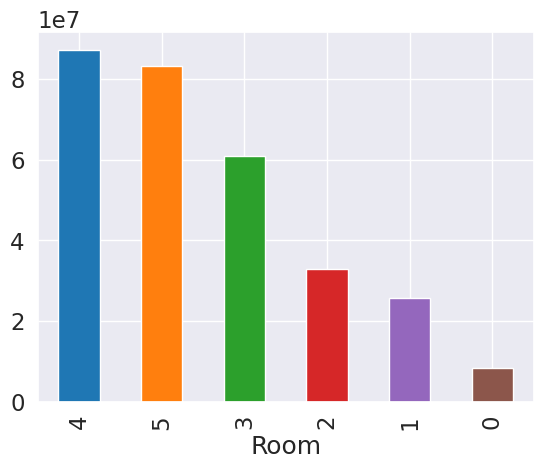

In [10]:
median_price = data.groupby('Room')['Price_per_sqm'].median().sort_values(ascending=False)
print(median_price.apply(lambda x: f"{x:,.0f}"))
data.groupby('Room')['Price_per_sqm'].median().sort_values(ascending=False).plot(kind='bar', color=colors)

<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:6px;">
        Description:
    </p>
    <p style="margin:0;">
        As the number of bedrooms increases, the price per square meter also rises. In this dataset, larger apartments with four to five rooms are clearly concentrated in premium neighborhoods, which makes their price per square meter approximately three to ten times higher than smaller units. The number of rooms therefore acts as a strong proxy for luxury location.
    </p>
</div>


<div style="
    background-color: #FFE1FF;
    border-left: 6px solid #660066;
    padding: 15px 20px;
    border-radius: 8px;
    margin: 15px 0;
    font-size: 14px;
    line-height: 1.5;    
">
Q6: In the same neighborhood, how much extra do Parking / Elevator / Warehouse add to the price?
</div>

Parking
False    17,049,180
True     38,053,097
Name: Price_per_sqm, dtype: object 
 **************************************************
Warehouse
False    19,344,262
True     36,170,213
Name: Price_per_sqm, dtype: object 
 **************************************************
Elevator
False    21,621,622
True     39,047,619
Name: Price_per_sqm, dtype: object 
 **************************************************


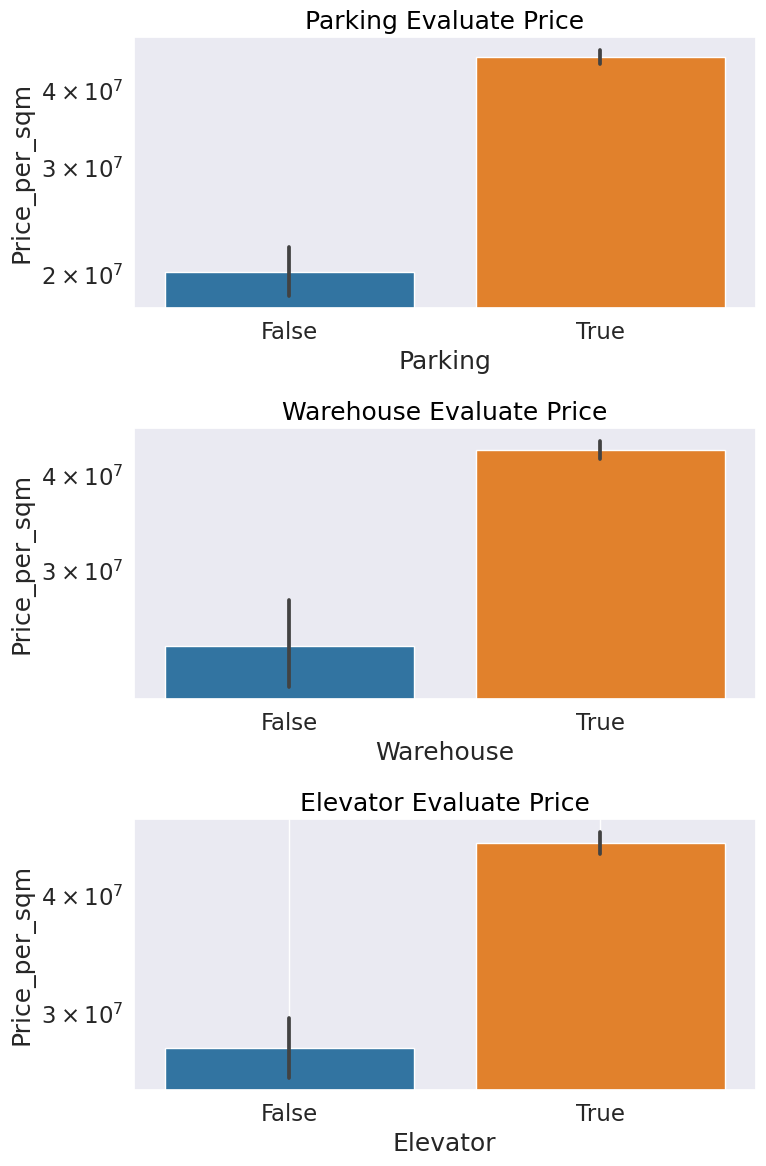

In [11]:
bool_col =['Parking', 'Warehouse', 'Elevator']
plt.figure(figsize=(8,12))
for idx , col in enumerate(bool_col):
    plt.subplot(3,1,idx+1)
    sns.barplot(data, x=col, y='Price_per_sqm', palette='tab10')
    plt.yscale('log')
    plt.title(f'{col} Evaluate Price' , color='black')
    #---Numerical summary
    print(data.groupby(col)['Price_per_sqm'].median().apply(lambda x: f"{x:,.0f}"),'\n','*'*50)
plt.tight_layout()
plt.grid()
plt.show()

<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:6px;">
        Description:
    </p>
    <p style="margin:0;">
        All three amenities add substantial value to the property. Having a parking space provides the largest increase in price, with an approximate 2.2 times boost, followed closely by the presence of an elevator and a warehouse.
    </p>
</div>


<div style="
    background-color: #FFE1FF;
    border-left: 6px solid #660066;
    padding: 15px 20px;
    border-radius: 8px;
    margin: 15px 0;
    font-size: 14px;
    line-height: 1.5;">

Q7: Are larger houses (high Area) proportionally more expensive, or is price per m² actually lower? (economy of scale)
</div>




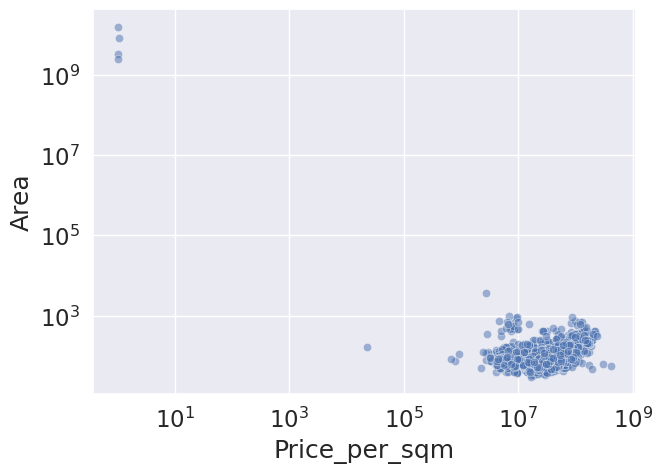

Median Area in neighborhoods: 
Address
Varamin - Beheshti    750.0
Absard                500.0
Gandhi                500.0
Lavasan               350.0
Argentina             301.5
Mahmoudieh            226.0
Vanak                 216.0
Elahieh               204.0
Araj                  202.0
Aqdasieh              195.0
Name: Area, dtype: float64


In [12]:
plt.figure(figsize=(7,5))
sns.scatterplot(data, x='Price_per_sqm', y='Area', alpha=0.5, palette='tab10')
plt.yscale('log')
plt.xscale('log')
plt.show()
#----------


print(f"Median Area in neighborhoods: \n{data.groupby('Address')['Area'].median().sort_values(ascending=False).head(10)}")
#outlier: Varamin - Beheshti    750.0 !!!!!!!!!!

<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:6px;">
        Description:
    </p>
    <p style="margin:0;">
        There is no clear economy of scale in Tehran’s housing market. Larger houses are not cheaper per square meter and are often located in premium areas. For a more accurate interpretation and more precise modeling, it is necessary to remove outliers, such as properties with an area greater than 10,000 square meters.
    </p>
</div>


<div style="
    background-color: #FFE1FF;
    border-left: 6px solid #660066;
    padding: 15px 20px;
    border-radius: 8px;
    margin: 15px 0;
    font-size: 14px;
    line-height: 1.5;">

Q8: Which neighborhoods have the highest variance in price? (heterogeneous vs luxury-only areas)
</div>




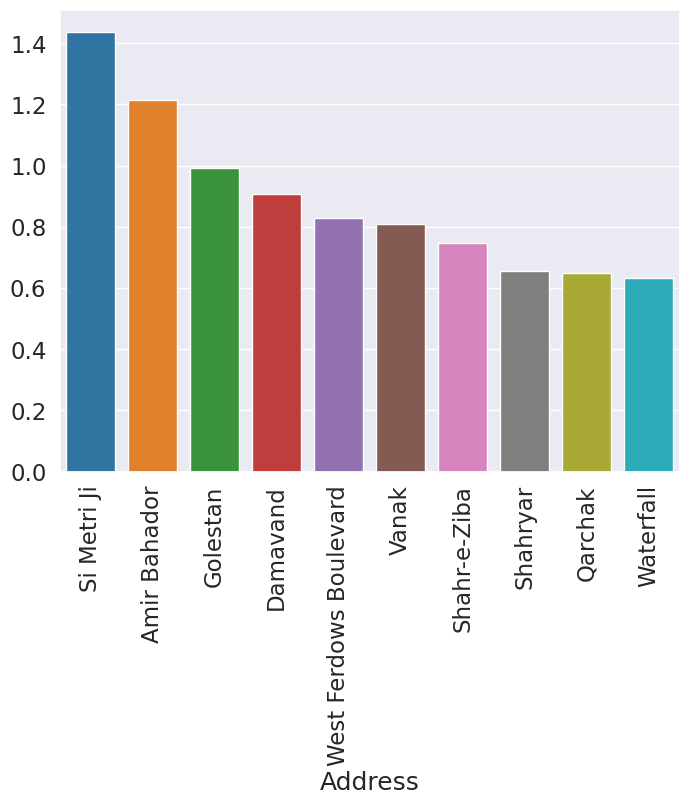

Variance:
Address
Si Metri Ji               1.43807185
Amir Bahador              1.21311006
Golestan                  0.99043255
Damavand                  0.90576973
West Ferdows Boulevard    0.82749841
Vanak                     0.80949751
Shahr-e-Ziba              0.74708154
Shahryar                  0.65448783
Qarchak                   0.64962002
Waterfall                 0.63150604
Name: Price_per_sqm, dtype: float64


In [13]:
add_var = data.groupby('Address')['Price_per_sqm'].std() / data.groupby('Address')['Price_per_sqm'].mean()
add_var = add_var.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=add_var.index, y=add_var.values, palette='tab10')
plt.tick_params(axis='x', rotation=90)
plt.show()
print(f'Variance:\n{add_var}')

<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:6px;">
        Description:
    </p>
    <p style="margin:0;">
        The most heterogeneous neighborhoods are primarily mid-range or suburban areas, such as Si Metri Ji, Amir Bahador, Damavand, Shahryar, Qarchak, and others. These areas contain both very inexpensive older units and some newer or luxury buildings. Pure luxury districts, including Elahieh, Zaferanieh, and Velenjak, do not appear among the top ten most heterogeneous neighborhoods because nearly every listing there is already expensive.
    </p>
</div>


<div style="
    background-color: #FFE1FF;
    border-left: 6px solid #660066;
    padding: 15px 20px;
    border-radius: 8px;
    margin: 15px 0;
    font-size: 14px;
    line-height: 1.5;">

Q9: Can we group Tehran houses into meaningful price tiers?  
(Cheap – Affordable – Expensive – Luxury)
</div>



<Axes: xlabel='price_level'>


price_level
Expensive     825
Cheap         813
Affordable    811
Luxury        799
Name: count, dtype: int64



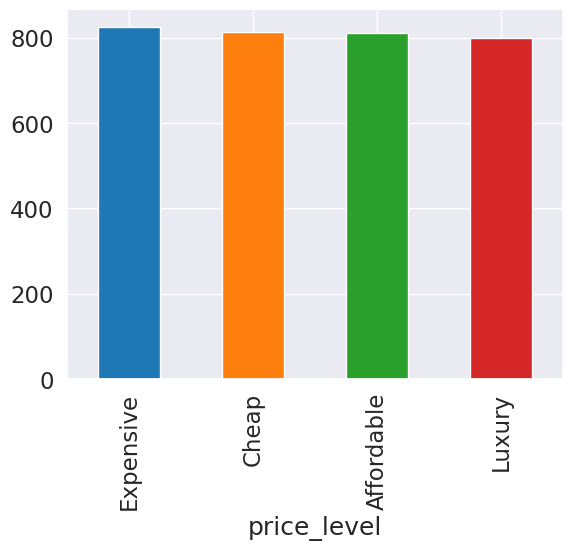

In [14]:
data['price_level'] = pd.qcut(data.Price, q=4, labels=['Cheap', 'Affordable', 'Expensive', 'Luxury'])

display(data.price_level.value_counts().plot(kind='bar', color=colors))
print(f'\n{data.price_level.value_counts()}\n')

<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:6px;">
        Description:
    </p>
    <p style="margin:0;">
        The distribution is very balanced across four parts.
    </p>
</div>


<div style="
    background-color: #FFE1FF;
    border-left: 6px solid #660066;
    padding: 15px 20px;
    border-radius: 8px;
    margin: 15px 0;
    font-size: 14px;
    line-height: 1.5;">

Q10: Can we group Tehran houses into meaningful size tiers?  
(Small – Medium – Large – Very Large)
</div>

<Axes: xlabel='area_size'>


area_size
Small         872
Very Large    805
Large         798
Medium        773
Name: count, dtype: int64



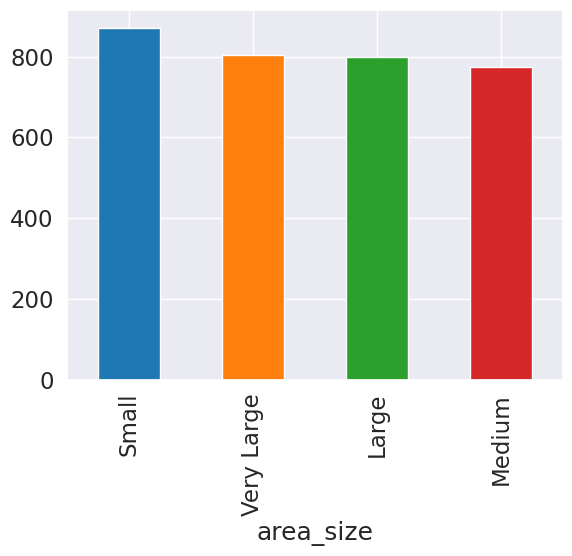

In [15]:
data['area_size'] = pd.qcut(data.Area, q=4, labels=['Small', 'Medium', 'Large', 'Very Large'])

display(data.area_size.value_counts().plot(kind='bar', color=colors))
print(f'\n{data.area_size.value_counts()}\n')

<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:6px;">
        Description:
    </p>
    <p style="margin:0;">
        The Small category has the highest number of houses (872). The counts for Very Large (805), Large (798), and Medium (773) are close to each other, indicating a fairly even distribution across area size categories.
    </p>
</div>


<div style="
    background-color: #FFE1FF;
    border-left: 6px solid #660066;
    padding: 15px 20px;
    border-radius: 8px;
    margin: 15px 0;
    font-size: 14px;
    line-height: 1.5;">

Q11: What percentage of Tehran listings include Parking, Warehouse, Room, and Elevator?
</div>




Parking
True     85.0
False    15.0
Name: proportion, dtype: float64
**************************************************
Warehouse
True     91.0
False     9.0
Name: proportion, dtype: float64
**************************************************
Room
2    56.0
3    21.0
1    19.0
4     2.0
5     1.0
0     0.0
Name: proportion, dtype: float64
**************************************************
Elevator
True     79.0
False    21.0
Name: proportion, dtype: float64
**************************************************


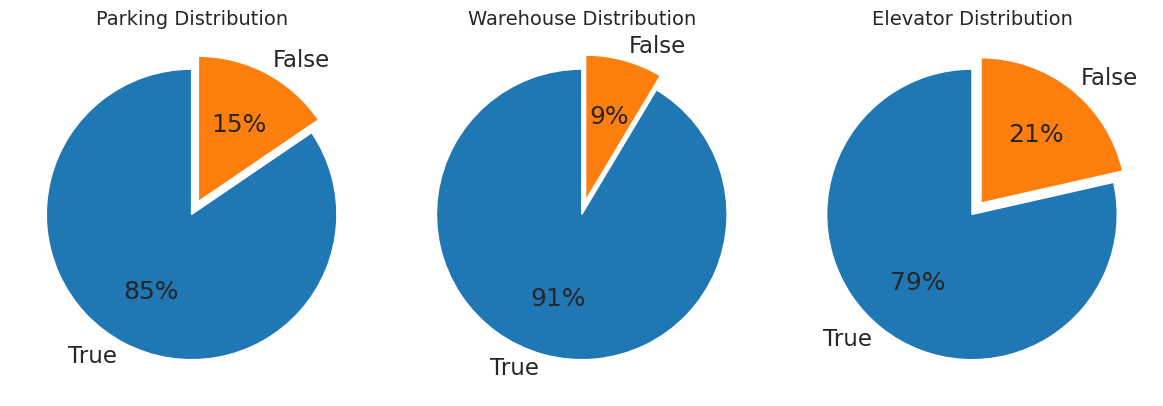

In [16]:
#Parking
print(f'{round(data.Parking.value_counts(normalize=True).mul(100))}')
print("*"*50)
#Warehouse
print(f'{round(data.Warehouse.value_counts(normalize=True).mul(100))}')
print("*"*50)
#Room
print(f'{round(data.Room.value_counts(normalize=True).mul(100))}')
print("*"*50)
#Elevator
print(f'{round(data.Elevator.value_counts(normalize=True).mul(100))}')
print("*"*50)

#----------------------------------------------visually
columns = ['Parking', 'Warehouse', 'Elevator']
titles = ['Parking', 'Warehouse', 'Elevator']

plt.figure(figsize=(12, 5))

for i, col in enumerate(columns, 1):
    plt.subplot(1, 3, i)
    sizes = data[col].value_counts()
    labels =sizes.index   
    plt.pie(sizes,labels=labels,  autopct='%1.0f%%', colors=colors, startangle=90, explode=(0, 0.1))
    plt.title(f'{titles[i-1]} Distribution', fontsize=14)

plt.tight_layout()
plt.show()

<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:6px;">
        Description:
    </p>
    <ul style="margin:0;padding-left:20px;">
        <li>
            <strong>Parking – 85%:</strong> Almost a must-have. Only 1 in 7 listings is without parking.
        </li>
        <li>
            <strong>Warehouse – 91%:</strong> Basically standard. 9 out of 10 homes come with storage; missing one is rare.
        </li>
        <li>
            <strong>Elevator – 79%:</strong> Very common, but still about 1 in 5 buildings lack it (usually low-rise or older ones).
        </li>
        <li>
            <strong>Bedrooms:</strong>
            <ul style="margin:4px 0 0 20px;padding:0;">
                <li>56% → 2-bed (the sweet spot)</li>
                <li>21% → 3-bed</li>
                <li>19% → 1-bed</li>
                <li>Only 3% → 4+ beds (mostly luxury)</li>
            </ul>
        </li>
    </ul>
</div>


<div style="
    background-color: #FFE1FF;
    border-left: 6px solid #660066;
    padding: 15px 20px;
    border-radius: 8px;
    margin: 15px 0;
    font-size: 14px;
    line-height: 1.5;">

Q12: Are larger apartments (3+ rooms) much more likely to have all three amenities?  
</div>

In [17]:
data['all_amenities'] = data['Parking'] & data['Warehouse'] & data['Elevator']
pd.crosstab(data.Room, data.all_amenities, normalize='index').mul(100).round()

all_amenities,False,True
Room,,
0,78.0,22.0
1,58.0,42.0
2,27.0,73.0
3,9.0,91.0
4,26.0,74.0
5,85.0,15.0


<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:6px;">
        Description:
    </p>
    <ul style="margin:0;padding-left:20px;">
        <li>1-bedroom and studios often miss at least one amenity.</li>
        <li>2-bedroom units are already quite good (73%).</li>
        <li>3-bedroom apartments almost always (91%) come with the full package.</li>
        <li>4-bedroom units are slightly lower than expected (74%) — probably because some are older renovated houses.</li>
        <li>5-bedroom units are surprisingly low (15%) — most are large villas without elevator or official parking.</li>
    </ul>
</div>

<div style="
    background-color: #FFE1FF;
    border-left: 6px solid #660066;
    padding: 15px 20px;
    border-radius: 8px;
    margin: 15px 0;
    font-size: 14px;
    line-height: 1.5;">

Q13: Top 10 neighborhoods with the highest number of listings?  
</div>

Top 10: Address
Punak                     148
West Ferdows Boulevard    133
Gheitarieh                133
Shahran                   123
Pardis                    123
Saadat Abad               120
Parand                    119
Shahr-e-Ziba               91
Jeyhoon                    88
Southern Janatabad         86
Name: count, dtype: int64


<Axes: xlabel='Address'>

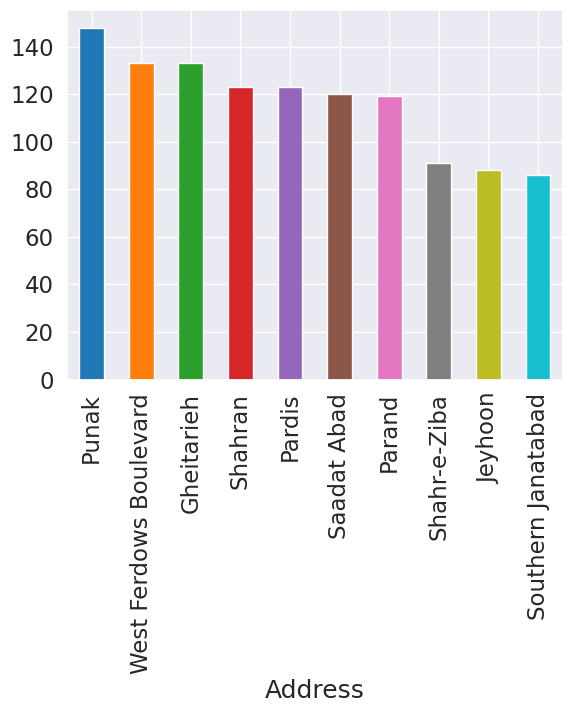

In [18]:
print('Top 10:', data.Address.value_counts().head(10))

display(data.Address.value_counts().head(10).plot(kind='bar', color=colors))

<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:6px;">
        Description:
    </p>
    <p style="margin:0;">
        West and Northwest Tehran completely dominate the listings. Six out of the top ten neighborhoods are in western areas, including Punak, West Ferdows, Shahran, Saadat Abad, Shahr-e-Ziba, and Southern Janatabad. Sellers in the west are clearly the most active on Divar at the moment. Northern areas such as Gheitarieh and Saadat Abad, along with satellite towns like Pardis and Parand, also show strong supply.
    </p>
</div>

<div style="
    background-color: #FFE1FF;
    border-left: 6px solid #660066;
    padding: 15px 20px;
    border-radius: 8px;
    margin: 15px 0;
    font-size: 14px;
    line-height: 1.5;">

Q14: How does the average price change across different apartment size categories?
</div>



In [19]:
area_size_feature = data.area_size.value_counts().to_frame()
area_size_feature['area_size_mean'] = data.groupby('area_size')['Price'].mean().apply(lambda x: f"{x:,.0f}")
display(area_size_feature)


,count,area_size_mean
area_size,,
Small,872,"1,712,050,057"
Very Large,805,"13,768,490,186"
Large,798,"4,229,041,228"
Medium,773,"2,382,418,952"


<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:6px;">
        Description:
    </p>
    <ul style="margin:0;padding-left:20px;">
        <li>Bigger apartments are significantly more expensive.</li>
        <li>Very Large apartments cost on average 8× more than Small ones and 3× more than Large ones.</li>
        <li>In Tehran, moving from “Large” to “Very Large” units (usually 160+ m²) means entering a completely different price league, mostly comprising luxury towers and villas in premium districts.</li>
    </ul>
</div>


<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin:0;">
        Quick Glance at Feature Correlations:
    </p>
</div>


Price            1.00000000
Price_per_sqm    0.80961017
Room             0.56986255
Parking          0.19329731
all_amenities    0.18195590
Elevator         0.10988832
Warehouse        0.10874656
Area             0.02102780
Name: Price, dtype: float64


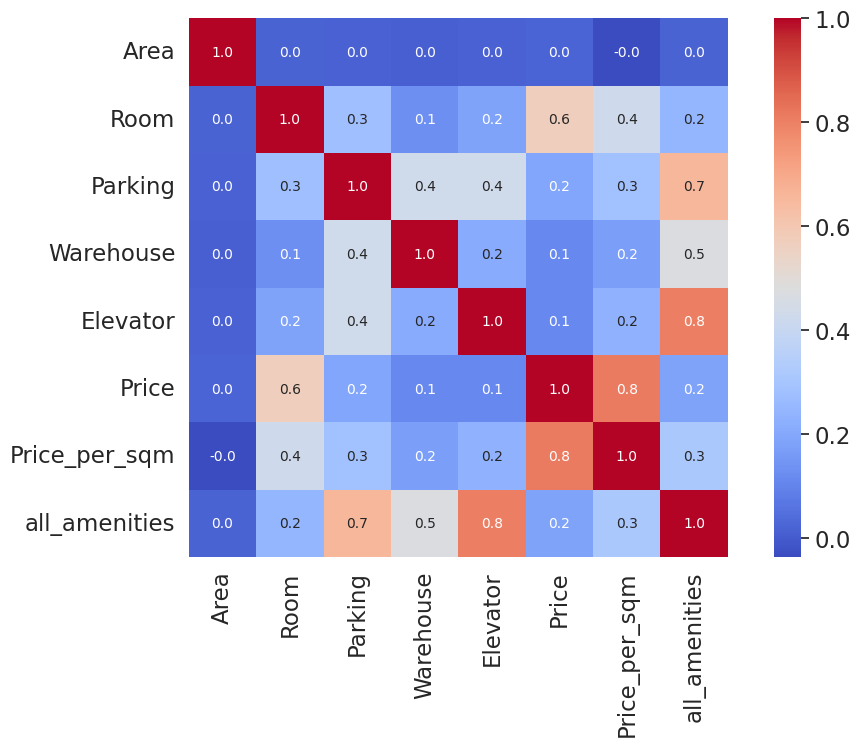

In [20]:
plt.figure(figsize=(12,7))
corr = data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, square=True, annot_kws={'size':10}, fmt='.1f', cmap='coolwarm', cbar=True)
print(corr.Price.sort_values(ascending=False))

<div style="
    background-color:#e6f9e6;
    border-left:6px solid #4caf50;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:16px;
    line-height:1.5;
">
    <p style="margin:0;font-weight:bold;">
        4. Preprocessing:
    </p>
</div>


In [21]:
data.describe()

,Area,Room,Price,Price_per_sqm
count,3.24800000e+03,3248.00000000,3.24800000e+03,3.24800000e+03
mean,9.36587247e+06,2.08805419,5.47811792e+09,4.16124292e+07
std,3.27790565e+08,0.76471631,8.26791600e+09,3.19496157e+07
min,3.00000000e+01,0.00000000,3.60000000e+06,1.00000000e+00
25%,7.00000000e+01,2.00000000,1.42000000e+09,2.00000000e+07
50%,9.00000000e+01,2.00000000,2.97750000e+09,3.50000000e+07
75%,1.22000000e+02,2.00000000,6.20000000e+09,5.50000000e+07
max,1.61600000e+10,5.00000000,9.24000000e+10,4.16666667e+08


<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1;
">
    <p style="margin:0;">
        <ul>
            <li>Since neighborhood names (Address) may contain typos, inconsistencies, or human errors, we are cleaning them up to ensure accuracy and avoid any potential issues.</li>
        </ul>
    </p>
</div>


In [22]:
pattern = r'[a-zA-Z]'
data[~data.Address.str.contains(pattern, na=False, case=False)]

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price_per_sqm,price_level,area_size,all_amenities


<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="margin:0;">
        No issues detected. All good :)
    </p>
</div>

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1;
">
    <p style="margin:0;font-weight:bold;">
        Outlier Detection:
    </p>
</div>

<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:6px;">
        Description:
    </p>
    <ul style="margin:0;padding-left:20px;">
        <li>From the EDA, we observed that both Price and Area are skewed.</li>
        <li>To handle outliers fairly, we will use the IQR method in the next steps.</li>
    </ul>
</div>

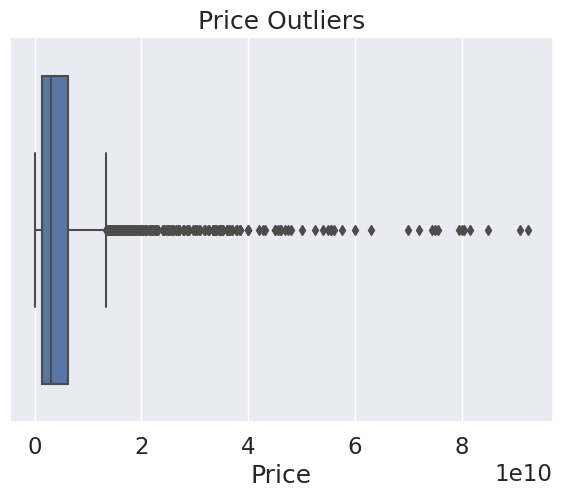

In [23]:
#part1
plt.figure(figsize=(7,5))
sns.boxplot(data, x='Price')
plt.title('Price Outliers')
plt.show()

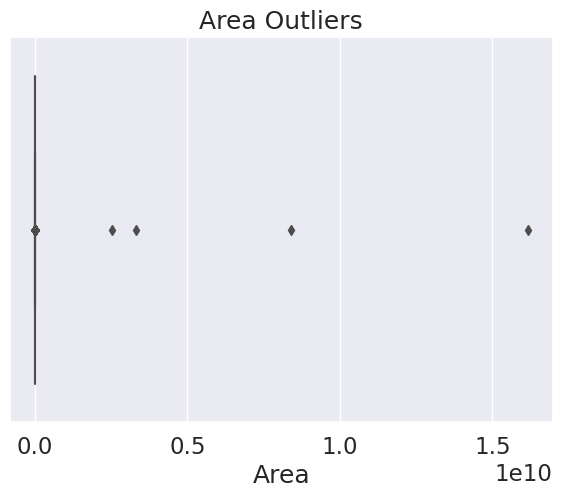

In [24]:
#part 1.2
plt.figure(figsize=(7,5))
sns.boxplot(data, x='Area')
plt.title('Area Outliers')
plt.show()

In [25]:
#part 1.3
print(f"Skew:\n{round(data[['Price','Area']].skew())}")

Skew:
Price     5.0
Area     42.0
dtype: float64


In [26]:
#part2
def lower_upper(x):
    Q1 = x.quantile(0.25)
    Q3 = x.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

lower_area, upper_area = lower_upper(data.Area)
lower_price, upper_price = lower_upper(data.Price)

print(f"Lower limit for area: {lower_area:0.2f}")
print(f"Upper limit for area: {upper_area:0.2f}")
print(f"Lower limit for price: {lower_price:,}")
print(f"Upper limit for price: {upper_price:,}")

Lower limit for area: -8.00
Upper limit for area: 200.00
Lower limit for price: -5,750,000,000.0
Upper limit for price: 13,370,000,000.0


<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:6px;">
        Description:
    </p>
    <ul style="margin:0;padding-left:20px;">
        <li>Negative bounds make no physical sense (area and price cannot be negative), so we will only apply realistic upper limits:</li>
        <li>Cap Area at 200 m²</li>
        <li>Cap Price at approximately 13.37 billion Toman</li>
    </ul>
</div>

In [27]:
#part3
area_outliers = np.where(data.Price > upper_price)
price_outliers = np.where(data.Area > upper_area)
total_outliers = np.union1d(area_outliers, price_outliers)
print(f'Number Of Area Outliers: {np.size(area_outliers)}')
print(f'Number Of Price Outliers: {np.size(price_outliers)}')
print("Total_Outliers:", len(total_outliers))

Number Of Area Outliers: 272
Number Of Price Outliers: 192
Total_Outliers: 319


In [28]:
#part4 - Droped...!
clean_data = data.drop(data.index[total_outliers])
print(clean_data.shape)
display(clean_data.sample(3))

(2929, 11)


,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price_per_sqm,price_level,area_size,all_amenities
1750,110,2,True,True,True,Islamshahr,2530000000.0,2.30000000e+07,Affordable,Large,True
94,65,2,True,True,True,Southern Program Organization,2270000000.0,3.49230769e+07,Affordable,Small,True
383,65,1,True,True,True,West Ferdows Boulevard,3900000000.0,6.00000000e+07,Expensive,Small,True


<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:6px;">
        Description:
    </p>
    <p style="margin:0;">
        Now we have more balanced data that is ready to be used for model fitting. Since we have removed a significant portion of the dataset, we can compare results using both versions (with outliers and without) to evaluate accuracy for each case.
    </p>
</div>

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="margin:0;font-weight:bold;">
        Encoding Step: Converting Strings to Model-Ready Features
    </p>
</div>

In [29]:
#part1 - Encoding Boolean Features:
bool_cols = ['Parking', 'Warehouse', 'Elevator']
clean_data[bool_cols] = clean_data[bool_cols].astype(int)
clean_data.sample(3)

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price_per_sqm,price_level,area_size,all_amenities
378,86,2,1,1,1,Southern Janatabad,3270000000.0,3.80232558e+07,Expensive,Medium,True
457,90,2,1,1,1,Shahr-e-Ziba,4099000000.0,4.55444444e+07,Expensive,Medium,True
2852,80,2,1,1,1,Gheitarieh,6000000000.0,7.50000000e+07,Expensive,Medium,True


In [30]:
#part2
#get_dummies (Address,  price_level, area_size) Features
Addresses = pd.get_dummies(clean_data[['Address','area_size']]).astype(np.int8)

#concat
clean_data = pd.concat([clean_data, Addresses], axis=1)

#Dropping Helper/Visualization Features(Price_per_sqm, price_level, all_amenities) And Address, area_size
clean_data.drop(columns=['Price_per_sqm','all_amenities', 'Address', 'price_level', 'area_size'], inplace=True)

In [31]:
#final dataset:
clean_data.sample(3)

,Area,Room,Parking,Warehouse,Elevator,Price,Address_Abazar,Address_Abbasabad,Address_Abuzar,Address_Afsarieh,Address_Ahang,Address_Air force,Address_Ajudaniye,Address_Alborz Complex,Address_Aliabad South,Address_Amir Bahador,Address_Amirabad,Address_Amirieh,Address_Andisheh,Address_Aqdasieh,Address_Araj,Address_Atabak,Address_Azadshahr,Address_Azarbaijan,Address_Azari,Address_Baghestan,Address_Bahar,Address_Baqershahr,Address_Beryanak,Address_Boloorsazi,Address_Central Janatabad,Address_Chahardangeh,Address_Chardangeh,Address_Chardivari,Address_Chidz,Address_Damavand,Address_Darabad,Address_Darakeh,Address_Darband,Address_Daryan No,Address_Dehkade Olampic,Address_Dezashib,Address_Dolatabad,Address_Dorous,Address_East Ferdows Boulevard,Address_East Pars,Address_Ekbatan,Address_Ekhtiarieh,Address_Elahieh,Address_Elm-o-Sanat,Address_Enghelab,Address_Eram,Address_Eskandari,Address_Fallah,Address_Farmanieh,Address_Fatemi,Address_Feiz Garden,Address_Firoozkooh,Address_Firoozkooh Kuhsar,Address_Garden of Saba,Address_Gheitarieh,Address_Ghiyamdasht,Address_Ghoba,Address_Gholhak,Address_Gisha,Address_Golestan,Address_Haft Tir,Address_Hakimiyeh,Address_Hashemi,Address_Hassan Abad,Address_Hekmat,Address_Heravi,Address_Heshmatieh,Address_Hor Square,Address_Islamshahr,Address_Islamshahr Elahieh,Address_Javadiyeh,Address_Jeyhoon,Address_Jordan,Address_Kahrizak,Address_Kamranieh,Address_Karimkhan,Address_Karoon,Address_Kazemabad,Address_Keshavarz Boulevard,Address_Khademabad Garden,Address_Khavaran,Address_Komeil,Address_Koohsar,Address_Kook,Address_Lavizan,Address_Mahallati,Address_Mahmoudieh,Address_Majidieh,Address_Malard,Address_Marzdaran,Address_Mehrabad,Address_Mehrabad River River,Address_Mehran,Address_Mirdamad,Address_Mirza Shirazi,Address_Moniriyeh,Address_Narmak,Address_Nasim Shahr,Address_Nawab,Address_Naziabad,Address_Nezamabad,Address_Niavaran,Address_North Program Organization,Address_Northern Chitgar,Address_Northern Janatabad,Address_Northern Suhrawardi,Address_Northren Jamalzadeh,Address_Ostad Moein,Address_Ozgol,Address_Pakdasht,Address_Pakdasht KhatunAbad,Address_Parand,Address_Parastar,Address_Pardis,Address_Pasdaran,Address_Persian Gulf Martyrs Lake,Address_Pirouzi,Address_Pishva,Address_Punak,Address_Qalandari,Address_Qarchak,Address_Qasr-od-Dasht,Address_Qazvin Imamzadeh Hassan,Address_Railway,Address_Ray,Address_Ray - Montazeri,Address_Ray - Pilgosh,Address_Razi,Address_Republic,Address_Robat Karim,Address_Rudhen,Address_Saadat Abad,Address_SabaShahr,Address_Sabalan,Address_Sadeghieh,Address_Safadasht,Address_Salehabad,Address_Salsabil,Address_Sattarkhan,Address_Seyed Khandan,Address_Shadabad,Address_Shahedshahr,Address_Shahr-e-Ziba,Address_ShahrAra,Address_Shahrake Apadana,Address_Shahrake Azadi,Address_Shahrake Gharb,Address_Shahrake Madaen,Address_Shahrake Qods,Address_Shahrake Quds,Address_Shahrake Shahid Bagheri,Address_Shahrakeh Naft,Address_Shahran,Address_Shahryar,Address_Shams Abad,Address_Shoosh,Address_Si Metri Ji,Address_Sohanak,Address_Southern Chitgar,Address_Southern Janatabad,Address_Southern Program Organization,Address_Southern Suhrawardi,Address_Tajrish,Address_Tarasht,Address_Taslihat,Address_Tehran Now,Address_Tehransar,Address_Telecommunication,Address_Tenant,Address_Thirteen November,Address_Vahidieh,Address_Vahidiyeh,Address_Valiasr,Address_Vanak,Address_Velenjak,Address_Villa,Address_Water Organization,Address_Waterfall,Address_West Ferdows Boulevard,Address_West Pars,Address_Yaftabad,Address_Yakhchiabad,Address_Yousef Abad,Address_Zafar,Address_Zaferanieh,Address_Zargandeh,Address_Zibadasht,area_size_Small,area_size_Medium,area_size_Large,area_size_Very Large
1508,79,2,1,1,1,3250000000.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

<div style="
    background-color:#e6f9e6;
    border-left:6px solid #4caf50;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:16px;
    line-height:1.5;
">
    <p style="margin:0;font-weight:bold;">
        5. Model Building:
    </p>
</div>


<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:6px;">
        Description:
    </p>
    <p style="margin:0;">
        First, we will train and evaluate several baseline models using default parameters to get a quick overview of performance. Then, we will select the top three models based on test metrics and proceed to hyperparameter tuning to further improve their performance.
    </p>
</div>


In [32]:
#Split Data:
X = clean_data.drop(columns='Price')
y = clean_data.Price

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2,random_state=0)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print('*'*30)
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (2343, 196)
X_test shape: (586, 196)
******************************
y_train shape: (2343,)
y_test shape: (586,)


In [33]:
# standard = StandardScaler()
# X_train =standard.fit_transform(X_train)
# X_test = standard.transform(X_test)

<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:6px;">
        Description:
    </p>
    <p style="margin:0;">
        All features are on a similar scale, so no additional feature scaling is required.
    </p>
</div>

In [34]:
model_name = []
train_score = []
test_score = []
rmse_score = []
mae_score = []
time_score = []
cols = ['Model_name', 'r2_score_For_Training','r2_score_For_Testing','RMSE_For_Testing',
        'MAE_For_Testing','Time_Score']
ml = []
def model_prediction(model):
    start_time = time.time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    trainscore = round(model.score(X_train, y_train),2)
    testscore = round(model.score(X_test, y_test),2)
    rmsescore = round(np.sqrt(mean_squared_error(y_test, y_pred)),2)
    maescore = round(mean_absolute_error(y_test, y_pred),2)
    end_time = time.time()
    timescore = round(end_time - start_time,4)
    #--------------------------------
    name = str(model).split('(')[0]
    model_name.append(name)
    train_score.append(trainscore)
    test_score.append(testscore)
    rmse_score.append(rmsescore)
    mae_score.append(maescore)
    time_score.append(timescore)
    ml.append((name, trainscore, testscore, rmsescore, maescore, timescore))
    #--------------------------------
    df = pd.DataFrame(ml, columns=cols)
    display(df.style.set_properties(**{'background-color': '#66FF66','border': '1px solid #ccc','color': 'black'}).hide(axis="index"))

    print('_'*85)
    print('_'*85)
    ml.clear()

In [35]:
model_list =[ Lasso(),Ridge(), ElasticNet(), DecisionTreeRegressor(),
             KNeighborsRegressor(), RandomForestRegressor(),
             LGBMRegressor(verbose=-1), XGBRegressor(),AdaBoostRegressor()]
for model in model_list:  
    model_prediction(model)

Model_name,r2_score_For_Training,r2_score_For_Testing,RMSE_For_Testing,MAE_For_Testing,Time_Score
Lasso,0.880000,0.840000,1228861701.330000,783124195.160000,0.576800


_____________________________________________________________________________________
_____________________________________________________________________________________


Model_name,r2_score_For_Training,r2_score_For_Testing,RMSE_For_Testing,MAE_For_Testing,Time_Score
Ridge,0.870000,0.840000,1219017623.670000,773584716.190000,0.053200


_____________________________________________________________________________________
_____________________________________________________________________________________


Model_name,r2_score_For_Training,r2_score_For_Testing,RMSE_For_Testing,MAE_For_Testing,Time_Score
ElasticNet,0.530000,0.550000,2040868148.690000,1478194568.960000,0.049400


...

_____________________________________________________________________________________
_____________________________________________________________________________________


Model_name,r2_score_For_Training,r2_score_For_Testing,RMSE_For_Testing,MAE_For_Testing,Time_Score
XGBRegressor,0.940000,0.850000,1185228469.240000,732412584.740000,0.268300


_____________________________________________________________________________________
_____________________________________________________________________________________


Model_name,r2_score_For_Training,r2_score_For_Testing,RMSE_For_Testing,MAE_For_Testing,Time_Score
AdaBoostRegressor,0.550000,0.540000,2070182540.430000,1576263785.290000,0.158900


_____________________________________________________________________________________
_____________________________________________________________________________________


<div style="
    background-color:#e6f9e6;
    border-left:6px solid #4caf50;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:16px;
    line-height:1.5;
">
    <p style="margin:0;font-weight:bold;">
        5-1. Checking All Models Score:
    </p>
</div>

In [36]:
all_models = pd.DataFrame({
    'Name':model_name,
    'R2_Train':train_score,
    'R2_Test':test_score,
    'RMSE':rmse_score,
    'MAE':mae_score,
    'Time':time_score
})
#--------------------------------------Display:
r2_cols = ['R2_Train', 'R2_Test']
error_cols = ['RMSE', 'MAE', 'Time']

all_models.sort_values(by='R2_Test', ascending=False).style \
  .highlight_max(subset=r2_cols, color='#a8e6cf') \
  .highlight_min(subset=error_cols, color='#ffcccb') \
  .set_properties(**{
      'border': '1px solid #ccc',
      'text-align': 'center'
  }) \
  .hide(axis='index')

Name,R2_Train,R2_Test,RMSE,MAE,Time
XGBRegressor,0.940000,0.850000,1185228469.240000,732412584.740000,0.268300
Lasso,0.880000,0.840000,1228861701.330000,783124195.160000,0.576800
Ridge,0.870000,0.840000,1219017623.670000,773584716.190000,0.053200
RandomForestRegressor,0.960000,0.810000,1345716323.890000,849310864.030000,2.049700
LGBMRegressor,0.800000,0.760000,1497479977.580000,972490911.650000,0.142900
DecisionTreeRegressor,0.990000,0.730000,1573170715.530000,943719210.140000,0.062600
KNeighborsRegressor,0.740000,0.580000,1968050411.990000,1320744948.840000,0.245600
ElasticNet,0.530000,0.550000,2040868148.690000,1478194568.960000,0.049400
AdaBoostRegressor,0.550000,0.540000,2070182540.430000,1576263785.290000,0.158900


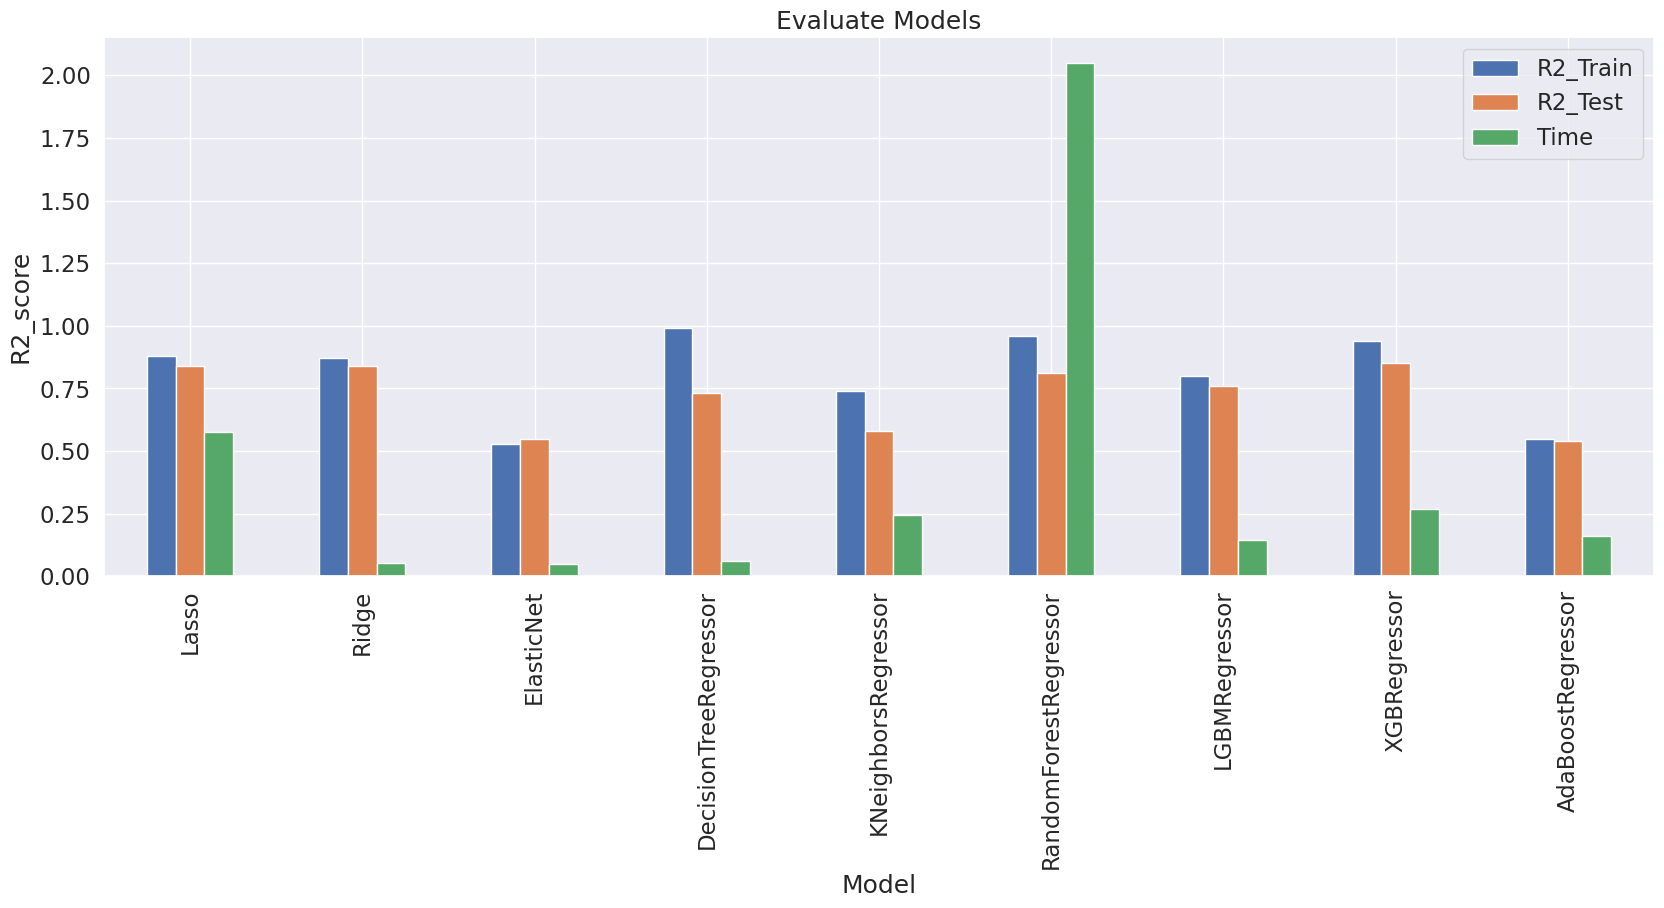

In [37]:
all_models.plot(x='Name', y=['R2_Train', 'R2_Test',  'Time'] , kind="bar" ,title="Evaluate Models" ,figsize=(20,7))
plt.ylabel('R2_score')
plt.xlabel('Model')
plt.show()

<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:6px;">
        Description:
    </p>
    <ul style="margin:0;padding-left:20px;">
        <li>XGBoost performs best overall, achieving the highest test R² with relatively low errors.</li>
        <li>Linear models (Lasso and Ridge) show stable and fast performance, indicating that simple relationships already explain much of the data.</li>
        <li>Decision Tree clearly overfits, with a large gap between training and test scores.</li>
        <li>Random Forest is more robust than a single tree but has the longest training time.</li>
        <li>Other models such as KNN, ElasticNet, and AdaBoost perform weaker and do not generalize well on this dataset.</li>
    </ul>
    <p style="font-weight:bold;margin-bottom:6px;margin-top:10px;">
        Conclusion:
    </p>
    <p style="margin:0;">
        We are going to use the three best models for hyper-parameter tuning: XGBRegressor, Ridge/Lasso, and Random Forest.
    </p>
</div>

<div style="
    background-color:#e6f9e6;
    border-left:6px solid #4caf50;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:16px;
    line-height:1.5;
">
    <p style="margin:0;font-weight:bold;">
        5-2. Hyper-Parameter Tuning for the Best Models:
    </p>
</div>


In [38]:
#Part1
model_name_best = []
train_score_best = []
test_score_best = []
rmse_score_best = []
mae_score_best = []
time_score_best = []
best_params = []

def find_best_params(model, parameter):
    start_time = time.time()
    grid_search = GridSearchCV(estimator = model, param_grid = parameter, cv=5)
    grid_search.fit(X_train, y_train)
    y_pred = grid_search.predict(X_test)
    end_time = time.time()
    time_score = round(end_time - start_time,4)
    #---------
    name = str(model).split('(')[0]
    model_name_best.append(name)
    train_score_best.append(round(grid_search.score(X_train, y_train),2))
    test_score_best.append(round(grid_search.score(X_test, y_test),2))
    rmse_score_best.append(round(np.sqrt(mean_squared_error(y_test, y_pred)),2))
    mae_score_best.append(round(mean_absolute_error(y_test, y_pred),2))
    time_score_best.append(time_score)
    best_params.append(grid_search.best_params_)
    

In [39]:
#part2
best_models = [XGBRegressor(), Ridge(), RandomForestRegressor()]

Param_xgbr = {
    'n_estimators': [100, 150, 200, 250],
    #'max_depth': [3, 5, 7],
    #'learning_rate': [0.03, 0.05, 0.1],
    #'subsample': [0.7, 0.85, 1.0],
    #'colsample_bytree': [0.7, 0.85, 1.0],
    #'min_child_weight': [1, 5, 10]
}

param_ridge = {'alpha': [0.001, 0.01, 0.1, 1, 10]}

Param_forest = {
    'n_estimators': [100, 150, 200, 250],
    #'max_depth': [10, 15, None],
    #'min_samples_split': [2, 5, 10],
    #'min_samples_leaf': [1, 2, 4],
    #'max_features': ['sqrt', 'log2']
}
params = [Param_xgbr, param_ridge, Param_forest]
for model, param in tqdm(zip(best_models, params), total=len(best_models), desc="Tuning Models"):
    find_best_params(model, param)

Tuning Models:   0%|          | 0/3 [00:00<?, ?it/s]

In [40]:
#Final Tuning Part
best_models = pd.DataFrame({
    'Name':model_name_best,
    'R2_Train':train_score_best,
    'R2_Test':test_score_best,
    'RMSE':rmse_score_best,
    'MAE':mae_score_best,
    'Time':time_score_best,
    'best_params':best_params
})
#--------------------------------------Display:
r2_cols = ['R2_Train', 'R2_Test']
error_cols = ['RMSE', 'MAE', 'Time']

best_models.sort_values(by='R2_Test', ascending=False).style \
  .highlight_max(subset=r2_cols, color='#a8e6cf') \
  .highlight_min(subset=error_cols, color='#ffcccb') \
  .set_properties(**{
      'border': '1px solid #ccc',
      'text-align': 'center'
  }) \
  .hide(axis='index')

Name,R2_Train,R2_Test,RMSE,MAE,Time,best_params
XGBRegressor,0.960000,0.850000,1163505600.120000,700151770.170000,5.506600,{'n_estimators': 200}
Ridge,0.880000,0.840000,1221760671.320000,777652776.330000,0.483500,{'alpha': 0.1}
RandomForestRegressor,0.960000,0.810000,1336319990.790000,845831230.200000,57.909100,{'n_estimators': 250}


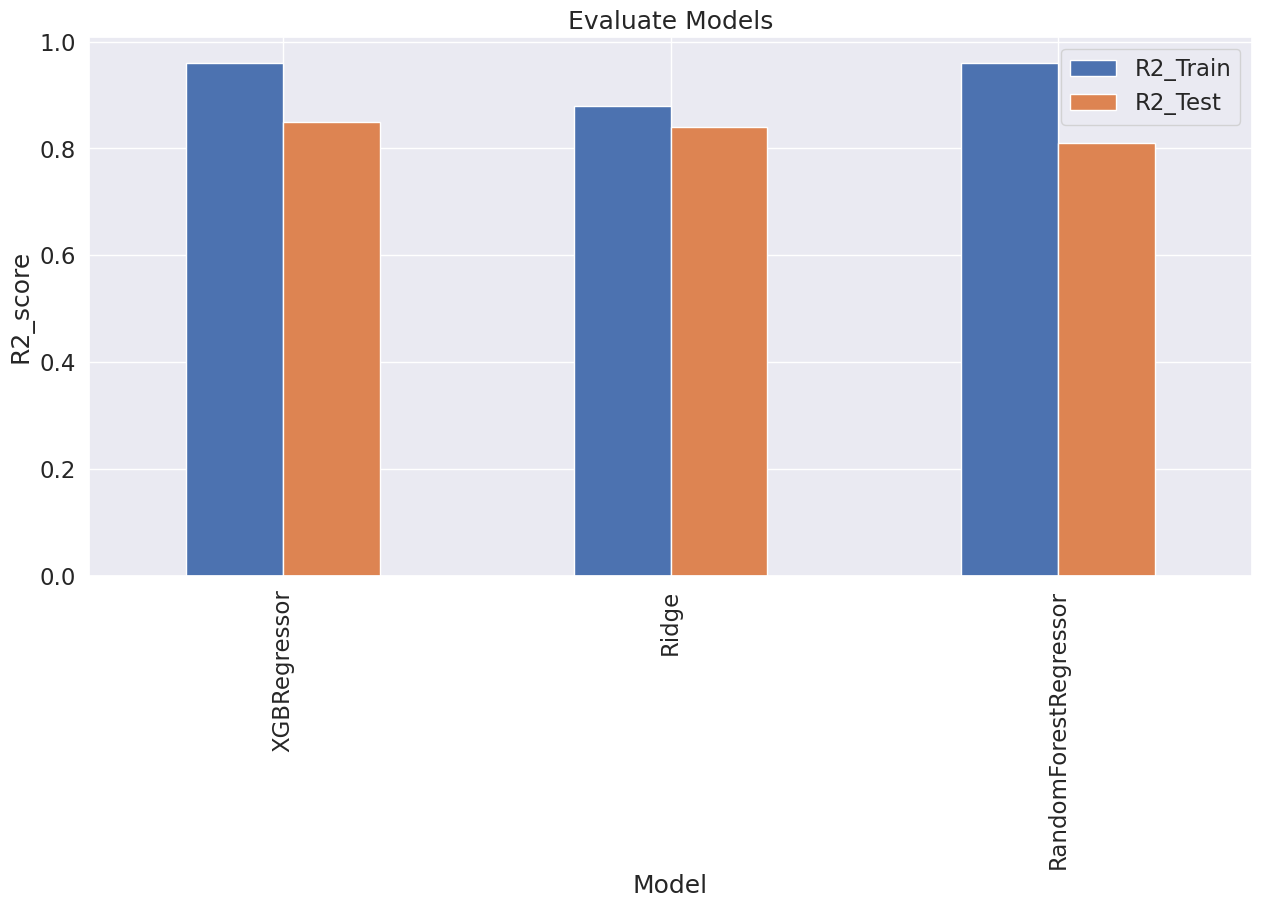

In [41]:
best_models.plot(x='Name', y = ['R2_Train' , 'R2_Test'] , kind="bar" ,title="Evaluate Models" ,figsize=(15,7))
plt.ylabel('R2_score')
plt.xlabel('Model')
plt.show()

<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:6px;">
        Description:
    </p>
    <ul style="margin:0;padding-left:20px;">
        <li>XGBoost leads with the highest test R² (0.85) and lowest errors, demonstrating strong generalization.</li>
        <li>Ridge provides stable performance (test R² 0.84) with minimal overfitting and excellent speed.</li>
        <li>Random Forest lags behind (test R² 0.81) due to overfitting and significantly longer training time.</li>
        <li>Final Decision: XGBoost is selected as the best overall model and will be saved for deployment.</li>
    </ul>
</div>

<div style="
    background-color:#e6f9e6;
    border-left:6px solid #4caf50;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:16px;
    line-height:1.5;
">
    <p style="margin:0;font-weight:bold;">
        6. Saving Model:
    </p>
</div>

In [42]:
# Model_Add = 'BestModel'
# joblib.dump(name, 'filename')
# best_model = joblib.load('filename')

<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:6px;">
        Project Summary
    </p>
    <ul style="margin:0;padding-left:20px;">
        <li>We started by loading the dataset and performing an initial inspection.</li>
        <li>Then, we conducted EDA guided by a series of predefined questions.</li>
        <li>Using feature engineering, we created new features and continued the analysis.</li>
        <li>Data preprocessing was carried out, and the data was prepared for modeling.</li>
        <li>Models were built with default hyperparameters, and the best ones were selected for hyperparameter tuning.</li>
        <li>We observed that XGBoost, Ridge, and Random Forest performed best, so hyperparameter tuning was applied to them, and ultimately XGBoost was chosen as the top model.</li>
        <li>Finally, the model was saved for future use.</li>
    </ul>
</div>

<div style="
    background-color:#e6f9e6;
    border-left:6px solid #4caf50;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:16px;
    line-height:1.5;
">
    <p style="margin:0;font-weight:bold;">
        7. Try It Yourself!
    </p>
    <p style="margin-top:8px;">
        Now it's your turn — fork this notebook and experiment with other powerful models such as GradientBoostingRegressor, CatBoostRegressor, and ExtraTreesRegressor. Compare their performance (with default or tuned parameters) against our top picks (XGBoost, Ridge, Random Forest) and see if you can beat the current best score. Happy modeling!
    </p>
</div>